# 01 — EDA dataset

In [1]:
import os
os.environ["POLARS_MAX_THREADS"] = "4"

from pathlib import Path
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

DATASET_DIR = Path("/mnt/d/VSF/VSF-MiniApp-Ecommerce/ai-recommendation/dataset")
PARQUET_DIR = DATASET_DIR / "parquet"
MONTHS = ["2019-Oct", "2019-Nov"]

PARQUET_DIR.mkdir(parents=True, exist_ok=True)
for m in MONTHS:
    pq = PARQUET_DIR / f"{m}.parquet"
    if not pq.exists():
        (pl.scan_csv(DATASET_DIR / f"{m}.csv", schema_overrides={"event_time": pl.String})
           .with_columns(pl.col("event_time").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S UTC"))
           .sink_parquet(pq, compression="zstd"))

scan = pl.scan_parquet(PARQUET_DIR / "*.parquet")

BLUE = "#2a78d6"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e6e3", "axes.axisbelow": True})
print(scan.collect_schema())

Schema({'event_time': Datetime(time_unit='us', time_zone=None), 'event_type': String, 'product_id': Int64, 'category_id': Int64, 'category_code': String, 'brand': String, 'price': Float64, 'user_id': Int64, 'user_session': String})


## 1. Quy mô theo tháng (xấp xỉ)

In [2]:
pl.concat([
    pl.scan_parquet(PARQUET_DIR / f"{m}.parquet")
      .select(
          pl.lit(m).alias("month"),
          pl.len().alias("events"),
          pl.col("user_id").approx_n_unique().alias("users"),
          pl.col("product_id").approx_n_unique().alias("products"),
          pl.col("user_session").approx_n_unique().alias("sessions"),
      )
      .collect(engine="streaming")
    for m in MONTHS
]).to_pandas()

,month,events,users,products,sessions
0,2019-Oct,42448764,2992529,148363,8692350
1,2019-Nov,67501979,3726349,165371,13734656


## 2. event_type + metadata thiếu (mức product)

In [3]:
event_types = (scan
  .group_by("event_type")
  .agg(pl.len().alias("count"))
  .sort("count", descending=True)
  .with_columns((pl.col("count") / pl.col("count").sum() * 100).round(2).alias("percent"))
  .collect(engine="streaming"))
display(event_types.to_pandas())

missing = (scan
  .group_by("product_id")
  .agg(
      pl.col("category_code").drop_nulls().first().alias("category_code"),
      pl.col("brand").drop_nulls().first().alias("brand"),
  )
  .select(
      pl.len().alias("products"),
      (pl.col("category_code").is_null().mean() * 100).round(1).alias("missing_category_pct"),
      (pl.col("brand").is_null().mean() * 100).round(1).alias("missing_brand_pct"),
  )
  .collect(engine="streaming"))
display(missing.to_pandas())

,event_type,count,percent
0,view,104335509,94.89
1,cart,3955446,3.60
2,purchase,1659788,1.51


,products,missing_category_pct,missing_brand_pct
0,206876,57.1,23.5


In [4]:
# Sample dữ liệu thiếu category_code / brand
display(scan.filter(pl.col("category_code").is_null()).head(5).collect(engine="streaming").to_pandas())
display(scan.filter(pl.col("brand").is_null()).head(5).collect(engine="streaming").to_pandas())

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 05:11:01,view,26400386,2053013563651392361,NaN,NaN,54.57,541311429,722e9c74-d6c4-486b-b6b9-8b727a6018d5
1,2019-11-01 05:11:01,view,34500027,2061717948468297988,NaN,NaN,8.87,542219174,e02ccf85-f306-41cc-b331-633004c8567d
2,2019-11-01 05:11:01,view,26401594,2053013563651392361,NaN,NaN,242.99,513333331,e4398b04-da6d-41c9-bbb3-445f46c261d4
3,2019-11-01 05:11:01,view,12709169,2053013553559896355,NaN,michelin,68.21,538957040,cb24428b-1944-4dbd-86f2-13d5737d89cf
4,2019-11-01 05:11:01,view,15700211,2053013559733912211,NaN,NaN,327.91,516926061,2b423fd7-6368-4670-b9fb-21cc1fdc87eb


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 05:11:01,view,26400386,2053013563651392361,NaN,NaN,54.57,541311429,722e9c74-d6c4-486b-b6b9-8b727a6018d5
1,2019-11-01 05:11:01,view,54900004,2146660887203676486,apparel.costume,NaN,77.22,527093952,0cb6950e-ed39-4809-bb68-d1fc20db62ed
2,2019-11-01 05:11:01,view,34500027,2061717948468297988,NaN,NaN,8.87,542219174,e02ccf85-f306-41cc-b331-633004c8567d
3,2019-11-01 05:11:01,view,26401594,2053013563651392361,NaN,NaN,242.99,513333331,e4398b04-da6d-41c9-bbb3-445f46c261d4
4,2019-11-01 05:11:01,view,17200559,2053013559792632471,furniture.living_room.sofa,NaN,591.78,524077760,6dadcb4e-76c8-4a9a-a848-d35b5a7ee631


## 3. Lưu lượng theo ngày → kiểm tra mốc time split

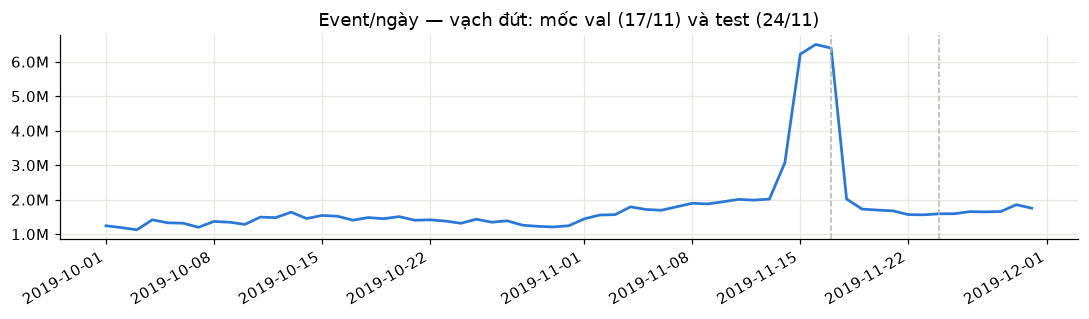

In [5]:
daily = (scan
  .group_by(pl.col("event_time").dt.date().alias("day"))
  .agg(pl.len().alias("n"))
  .sort("day")
  .collect(engine="streaming")
  .to_pandas())

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(daily["day"], daily["n"], color=BLUE, linewidth=1.8)
for d in ["2019-11-17", "2019-11-24"]:  # mốc val / test
    ax.axvline(pd.Timestamp(d), color="#b5b4ae", linestyle="--", linewidth=1)
ax.set_title("Event/ngày — vạch đứt: mốc val (17/11) và test (24/11)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## Kết luận — số liệu chính xác (đã chạy và kiểm chứng 30/07/2026)

| Câu hỏi | Kết quả | Hệ quả cho Phase 2 |
|---|---|---|
| Quy mô | 110M events, 3.8M users, 207K products, 23M sessions | Đủ dữ liệu học Item2Vec |
| event_type | view **94.9%**, cart 3.6%, purchase 1.5% | Không áp rule view<cart<purchase; event_type để ablation (RQ4) |
| Metadata thiếu (mức product) | **57%** không có category_code, **23%** không có brand | Metadata fallback yếu hơn kỳ vọng — cold-start chủ yếu dựa `category_id` (luôn có) |
| Popularity skew | Median 51 events/product, max 1.14M; 81K products <30 events | Cần theo dõi coverage/long-tail; cân nhắc subsample khi train Item2Vec |
| Session | 23M sessions, **49% có ≥2 products** (dùng được để train), p99 = 35 events, max 4128 (bot) | Lọc session ≥2 items, cắt tối đa 100 khi build sequences |
| Time split | train ≤16/11, val 17–23/11, test 24–30/11 | Đỉnh sale giữa tháng 11 nằm trọn trong train |

**Kết quả sessionization** (đã chạy 30/07, data trung gian đã dọn — tái tạo được từ CSV khi cần): train 8.47M / val 1.60M / test 1.21M sessions; vocab **187,916** products; cold-start target val 0.67%.

**Baseline (trên val, leave-last-out):** B0-global HR@20=7.4% · B0-category HR@20=25.0% · **B1 co-visitation HR@20=44.4%, NDCG@20=0.224, coverage 92%** — mốc mà B2 (Item2Vec) / K1 / RQ1 (Semantic ID) phải vượt.